<a href="https://colab.research.google.com/github/kaitorr07/Kaito-Raymundo-ML-ITAI1371/blob/Projects/FinalProject_KaitoRaymundo_ITAI_1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Package to Import Dataset:**

In [4]:
pip install ucimlrepo

# **Main Code:**

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer


# Dataset (Link: https://archive.ics.uci.edu/static/public/336/data.csv)
chronic_kidney_disease = fetch_ucirepo(id=336)


X = chronic_kidney_disease.data.features
y = chronic_kidney_disease.data.targets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Converting to 1-D Array
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

numeric_features = X_train.select_dtypes(include='number')
categorical_features = X_train.select_dtypes(exclude='number')

# Cleaning data and preprocessing
numeric_transformer = make_pipeline(SimpleImputer(strategy='mean'), StandardScaler())
categorical_transformer = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore'))
preprocessor = make_column_transformer((numeric_transformer, numeric_features.columns),(categorical_transformer, categorical_features.columns))

# Pipeline
model_pipeline = make_pipeline(preprocessor, RandomForestClassifier(random_state=42))

# Fitting the pipeline
model_pipeline.fit(X_train, y_train)

# Prediction
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Performance: {model_pipeline.score(X_test, y_test):2%}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Classification Report:\n{report}")

Performance: 100.000000%
Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

         ckd       1.00      1.00      1.00        76
      notckd       1.00      1.00      1.00        44

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



# **Finding/Tuning Hyperparameters:**

In [ ]:
from sklearn.model_selection import GridSearchCV


param_grid = {'randomforestclassifier__n_estimators': [100, 200, 300], 'randomforestclassifier__max_depth': [10, 20, 30]}

grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_:.2%}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__n_estimators': 100}
Best Score: 97.50%


# **Applying Hyperparameters to Create the Best Model:**

In [ ]:
best_model_pipeline = grid_search.best_estimator_

y_pred_tuned = best_model_pipeline.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
report_tuned = classification_report(y_test, y_pred_tuned)
cross_val_score_tuned = cross_val_score(model_pipeline, X_train, y_train, cv=25).mean()

print(f"\nPerformance of the Tuned Model: {best_model_pipeline.score(X_test, y_test):2%}")
print(f"Accuracy with Tuned Model: {accuracy_tuned:.2f}")
print(f"Classification Report with Tuned Model:\n{report_tuned}")
print(f"Cross Validation Score with Tuned Model:\n {cross_val_score(model_pipeline, X_train, y_train, cv=25).mean():.2%}")


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=25.
  warnings.warn(



Performance of the Tuned Model: 100.000000%
Accuracy with Tuned Model: 1.00
Classification Report with Tuned Model:
              precision    recall  f1-score   support

         ckd       1.00      1.00      1.00        76
      notckd       1.00      1.00      1.00        44

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=25.
  warnings.warn(


Cross Validation Score with Tuned Model:
 98.24%


# **Visualizing the Most Important Features used by the Model:**

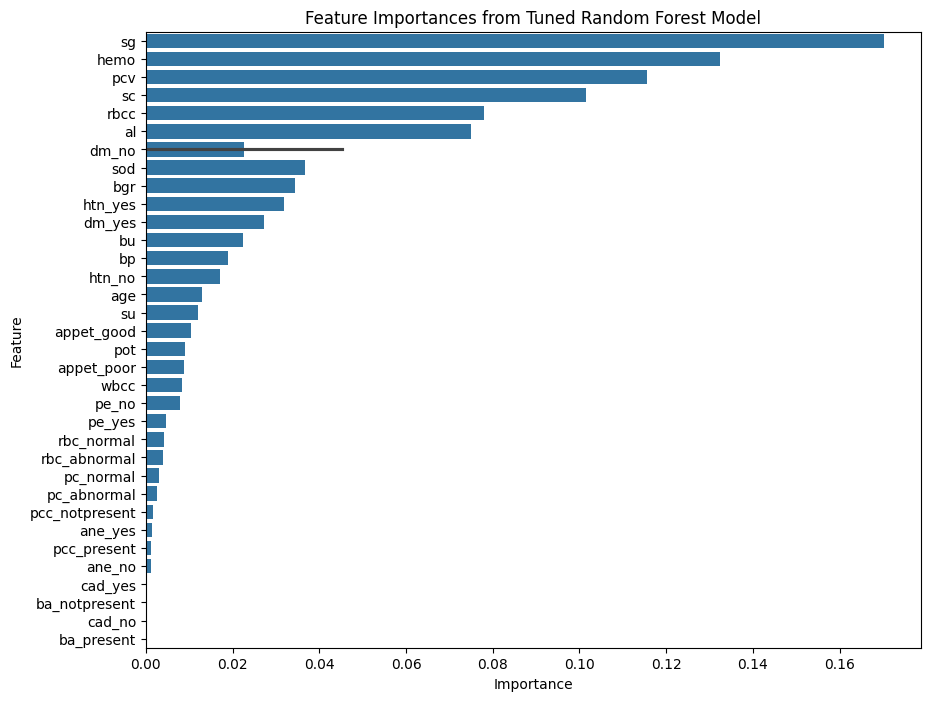

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

random_forest_model = best_model_pipeline.named_steps['randomforestclassifier']
feature_importances = random_forest_model.feature_importances_
preprocessor_fitted = best_model_pipeline.named_steps['columntransformer']
processed_feature_names = preprocessor_fitted.get_feature_names_out()

# Fixing feature names for QoL and increased readability
cleaned_feature_names = []
for feature_name in processed_feature_names:
    if feature_name.startswith('standardscaler__'):
        cleaned_feature_names.append(feature_name.replace('standardscaler__', ''))
    elif feature_name.startswith('onehotencoder__'):
        cleaned_feature_names.append(feature_name.replace('onehotencoder__', ''))
    elif feature_name.startswith('pipeline-1__'):
        cleaned_feature_names.append(feature_name.replace('pipeline-1__', ''))
    elif feature_name.startswith('pipeline-2__'):
        cleaned_feature_names.append(feature_name.replace('pipeline-2__', ''))
    else:
        cleaned_feature_names.append(feature_name)

cleaned_feature_names = [name.replace('dm_\tno', 'dm_no') for name in cleaned_feature_names]

importance_df = pd.DataFrame({'Feature': cleaned_feature_names,'Importance': feature_importances})

# Sorting by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Tuned Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# **Summary of Plot:**
**According to this plot, the five most important indicators of CKD are specific gravity levels, hemoglobin levels, packed cell volumes, serum creatinine levels, and red blood cell counts. Doctors should still consider the other twenty indicators, but these five should be prioritized for the most accurate diagnosis.**